## **Bayesian Linear Regression**

In [1]:
%pip install pymc pytensor

In [37]:
import numpy as np
import arviz as az
import matplotlib.pyplot as plt
import requests
import io
import csv
import pandas as pd
import pymc as pm



---



### **Exercise: Simple Linear Regression**

In [28]:
np.random.seed(123)

N = 100
x = np.random.normal(10,1,N)
eps = np.random.normal(0,0.5,size=N)

alpha_real = 2.5
beta_real = 0.9

y_real = alpha_real + beta_real*x

y = y_real + eps

print(f"x, {x[: 5]}, ... {x[-2 :]}")
print(f"y, {y[: 5]}, ... {y[-2 :]}")


# what happens if you center your data around the origin?
"""
y = y - np.mean(y)
x = x - np.mean(x)
y_real = y_real - np.mean(y_real)
"""

x, [ 8.9143694  10.99734545 10.2829785   8.49370529  9.42139975], ... [10.37940061  9.62082357]
y, [10.8439598  11.40866694 12.11081297 11.44348672 10.96694678], ... [11.67082969 11.04976808]


'\ny = y - np.mean(y)\nx = x - np.mean(x)\ny_real = y_real - np.mean(y_real)\n'

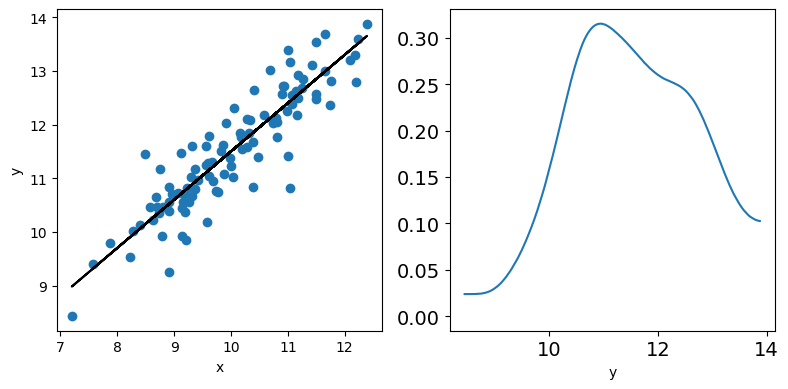

In [29]:
_, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(x,y,'C0o')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[0].plot(x,y_real,'k')
az.plot_kde(y,ax=ax[1])
ax[1].set_xlabel('y')
plt.tight_layout()

In PyMC, the with `pm.Model() as model:` block defines a model context: all random variables created inside the block are automatically added to that probabilistic model.

(high-level) PyMC represents the Bayesian model as a computational graph, where nodes are random variables or deterministic transformations, and edges encode probabilistic or functional dependencies among them. This graph allows PyMC to compute log-probabilities and gradients needed for MCMC sampling.

In [30]:
with pm.Model() as model_lin:
    α = pm.Normal('α', mu=0, sigma=10)
    β = pm.Normal('β', mu=0, sigma=1)
    ϵ = pm.HalfCauchy('ϵ', 5)

    μ = pm.Deterministic('μ', α + β * x)

    # Deterministic nodes are computed outside the main computation graph,
    # which can be optimized as though there was no Deterministic nodes.
    # Whereas the optimized graph can be evaluated thousands of times during a NUTS step,
    # the Deterministic quantities are just computeed once at the end of the step,
    # with the final values of the other random variables

    y_pred = pm.Normal('y_pred', mu=α + β * x, sigma=ϵ, observed=y)

    trace_lin = pm.sample(1000, tune=1000)

Output()

In [31]:
trace_lin.posterior.sizes

Frozen({'chain': 2, 'draw': 1000, 'μ_dim_0': 100})

array([[<Axes: title={'center': 'α'}>, <Axes: title={'center': 'α'}>],
       [<Axes: title={'center': 'β'}>, <Axes: title={'center': 'β'}>],
       [<Axes: title={'center': 'ϵ'}>, <Axes: title={'center': 'ϵ'}>]],
      dtype=object)

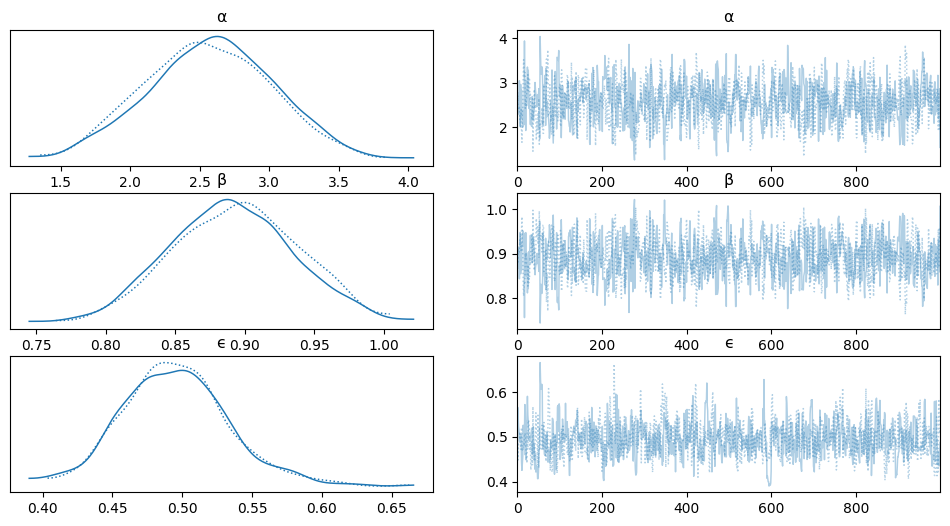

In [32]:
az.plot_trace(trace_lin, var_names=['α', 'β', 'ϵ'])

In [33]:
az.summary(trace_lin)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,2.572,0.450,1.706,3.369,0.018,0.010,660.0,1010.0,1.0
β,0.892,0.044,0.816,0.979,0.002,0.001,670.0,969.0,1.0
μ[0],10.523,0.072,10.387,10.659,0.002,0.001,844.0,1281.0,1.0
μ[1],12.381,0.064,12.257,12.497,0.002,0.001,1236.0,1581.0,1.0
μ[2],11.744,0.050,11.652,11.842,0.001,0.001,1794.0,1626.0,1.0
...,...,...,...,...,...,...,...,...,...
μ[96],10.524,0.072,10.388,10.660,0.002,0.001,844.0,1281.0,1.0
μ[97],10.275,0.081,10.130,10.437,0.003,0.002,782.0,1296.0,1.0
μ[98],11.830,0.051,11.737,11.929,0.001,0.001,1760.0,1627.0,1.0
μ[99],11.153,0.053,11.056,11.257,0.001,0.001,1326.0,1526.0,1.0


### MCMC diagnostics

When we sample from a posterior distribution using MCMC, we need to check whether the numerical sampling is reliable. Common diagnostics include:

| Quantity | Meaning | Desired behavior |
|---|---|---|
| `mcse_mean` | Monte Carlo standard error of the estimated posterior mean | Small compared with posterior `sd` |
| `mcse_sd` | Monte Carlo standard error of the estimated posterior standard deviation | Small compared with posterior `sd` |
| `ess_bulk` | Effective sample size in the central, high-probability region of the posterior | Large |
| `ess_tail` | Effective sample size in the tails of the posterior | Large |
| `r_hat` | Convergence diagnostic comparing multiple chains | Close to 1 |

The posterior standard deviation, `sd`, describes the **uncertainty of the parameter**.

The Monte Carlo standard errors, `mcse_mean` and `mcse_sd`, describe the **numerical uncertainty due to finite MCMC sampling**.

A useful rule of thumb is:

$$
\texttt{mcse_mean} \ll \texttt{sd},
\qquad
\texttt{r_hat} \approx 1,
\qquad
\texttt{ess_bulk}, \texttt{ess_tail} \text{ large}.
$$

In practice, values such as

$$
\texttt{r_hat} \lesssim 1.01
$$

are usually considered a good sign of convergence.

The effective sample size, ESS, accounts for the fact that MCMC samples are correlated (this is related to the autocorrelation in the chain). Therefore, even if we generate many samples, the number of effectively independent samples may be smaller.

<Axes: xlabel='α', ylabel='β'>

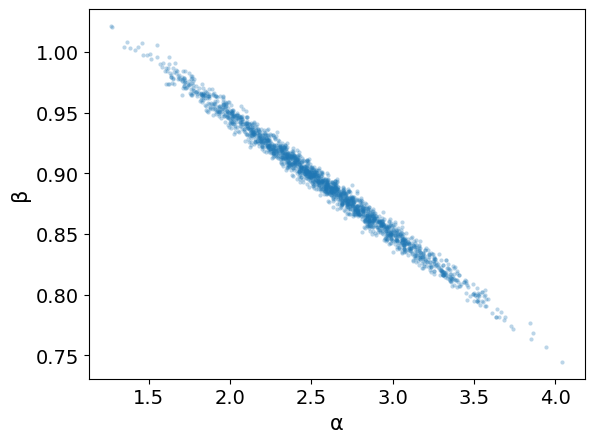

In [34]:
az.plot_pair(trace_lin,var_names=['α','β'], scatter_kwargs={'alpha': 0.3})




**Notes**

If we did not transorm our data:

* Correlation is a direct consequence of our assumption/model.

* An increase in the slope means a decrease of the intercept and viceversa.

* The line is constrained to pass through the mean of the data (this is actually "relaxed" in the Bayesian model, but still partly true).

In some cases, it could be a good idea transforming our data through:



```
x' = x - <x>
```









<Axes: >

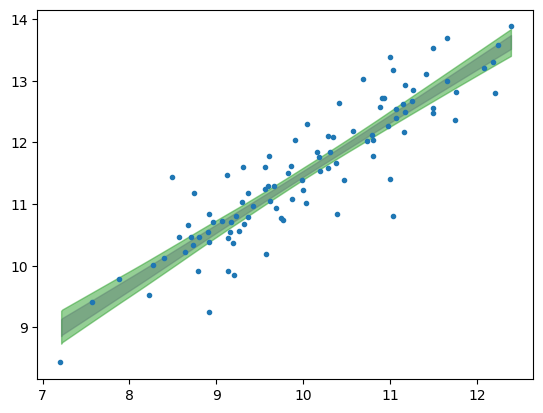

In [35]:
plt.plot(x,y,'C0.')
az.plot_hdi(x,trace_lin.posterior['μ'],color='C4',hdi_prob=.68)
az.plot_hdi(x,trace_lin.posterior['μ'],color='C2',hdi_prob=.95)



---



### **Exercise: Polynomial Regression**

**Linear vs Polynomial Regression**

Polynomial regression is still a form of **linear regression** because the model is linear in its coefficients, even though it is nonlinear in the input variable \(x\). For example, $y = \beta_0 + \beta_1 x + \beta_2 x^2 + \cdots + \beta_p x^p$ is nonlinear as a function of $x$, but linear in the parameters $\beta_0, \beta_1, \ldots, \beta_p$.

In [38]:
target_url = 'https://raw.githubusercontent.com/cfteach/brds/main/datasets/anscombe.csv'

download = requests.get(target_url).content
ans = pd.read_csv(io.StringIO(download.decode('utf-8')))

x = ans[ans.group == 'II']['x'].values
y = ans[ans.group == 'II']['y'].values
x = x - x.mean()

**Note**

*Anscombe's quartet comprises four data sets that have nearly identical simple descriptive statistics, yet have very different distributions and appear very different when graphed.*

https://en.wikipedia.org/wiki/Anscombe%27s_quartet

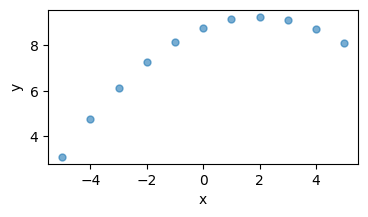

In [39]:
f=plt.figure()
f.set_figwidth(4)
f.set_figheight(2)
plt.xlabel('x')
plt.ylabel('y')
plt.plot(x,y,'C0.',alpha=0.6, markersize=10)

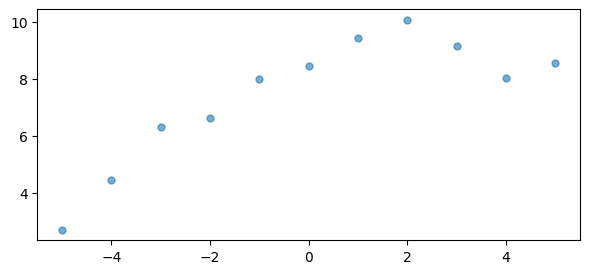

In [41]:
yn = y.copy()

yn += np.random.normal(0,.5, len(yn))

f = plt.figure(figsize=(7,3))
plt.plot(x,yn,'C0.',alpha=0.6, markersize=10)

In [67]:
with pm.Model() as model_poly:
  alpha = pm.Normal('alpha',mu=y.mean(),sigma=1)
  beta1 = pm.Normal('beta1',mu=0.,sigma=1)
  beta2 = pm.Normal('beta2',mu=0.,sigma=1)
  epsilon = pm.HalfCauchy('epsilon', 5)

  mu = pm.Deterministic('mu',alpha + beta1*x + beta2*x*x)

  y_pred = pm.Normal('y_pred', mu=mu, sigma = epsilon, observed = yn)

  idata_poly = pm.sample(2000, tune = 2000)


Output()

array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta1'}>,
        <Axes: title={'center': 'beta1'}>],
       [<Axes: title={'center': 'beta2'}>,
        <Axes: title={'center': 'beta2'}>],
       [<Axes: title={'center': 'epsilon'}>,
        <Axes: title={'center': 'epsilon'}>],
       [<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

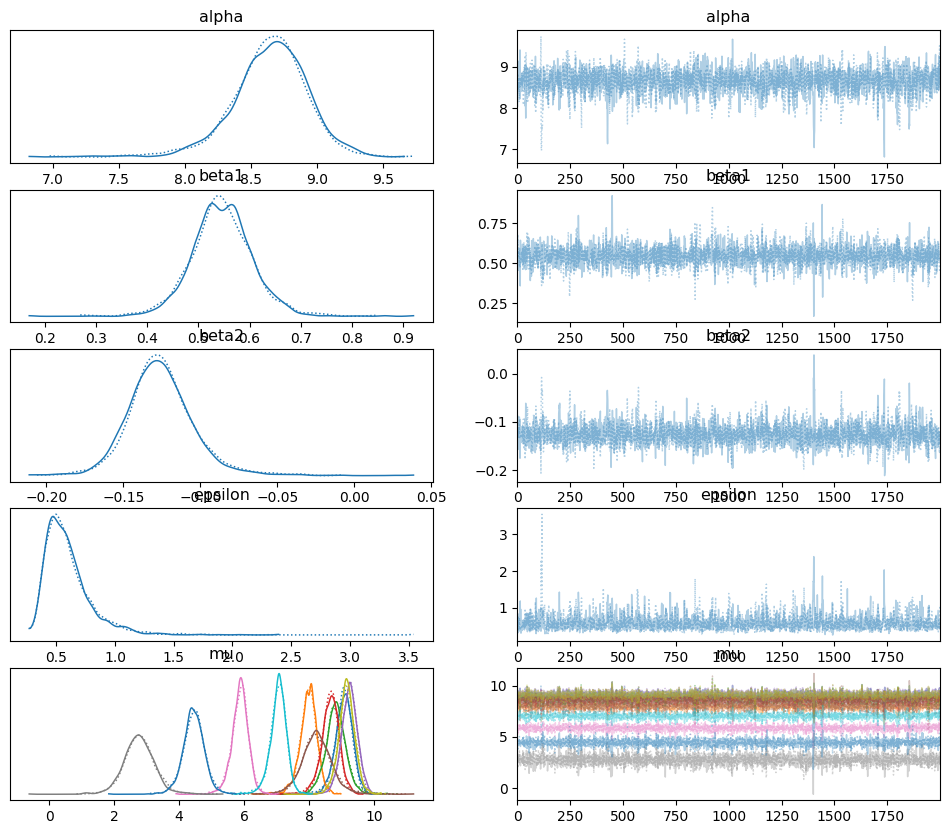

In [68]:
az.plot_trace(idata_poly)

In [69]:
res2 = az.summary(idata_poly)
print(res2)

          mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha    8.640  0.287   8.068    9.138      0.007    0.010    1970.0   
beta1    0.546  0.060   0.430    0.658      0.001    0.002    2349.0   
beta2   -0.125  0.022  -0.165   -0.085      0.001    0.001    1994.0   
epsilon  0.597  0.206   0.315    0.965      0.006    0.012    1352.0   
mu[0]    9.060  0.277   8.539    9.565      0.007    0.010    2039.0   
mu[1]    7.968  0.279   7.437    8.475      0.007    0.010    2048.0   
mu[2]    8.817  0.337   8.126    9.397      0.007    0.009    2698.0   
mu[3]    8.640  0.287   8.068    9.138      0.007    0.010    1970.0   
mu[4]    9.230  0.257   8.749    9.701      0.006    0.007    2208.0   
mu[5]    8.234  0.492   7.277    9.123      0.010    0.015    2466.0   
mu[6]    5.873  0.265   5.330    6.324      0.005    0.006    3045.0   
mu[7]    2.774  0.484   1.888    3.667      0.010    0.013    2744.0   
mu[8]    9.149  0.262   8.681    9.647      0.005    0.006    25

<Axes: >

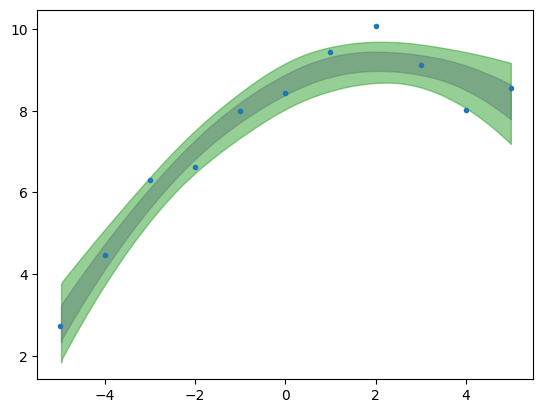

In [70]:
plt.plot(x,yn,'C0.')
az.plot_hdi(x,idata_poly.posterior['mu'],color='C4',hdi_prob=.68)
az.plot_hdi(x,idata_poly.posterior['mu'],color='C2',hdi_prob=.95)

**Posterior Predictive checks**

A **posterior predictive check** asks:

> Can the fitted Bayesian model generate fake data that look like the observed data?

After fitting the model, we have

$$
p(\alpha,\beta,\epsilon \mid \mathcal{D}).
$$

We then generate replicated data from the posterior predictive distribution:

$$
p(y^{\mathrm{rep}} \mid \mathcal{D})
=
\int
p(y^{\mathrm{rep}} \mid \alpha,\beta,\epsilon)\,
p(\alpha,\beta,\epsilon \mid \mathcal{D})\,
d\alpha\,d\beta\,d\epsilon.
$$

In practice:

$$
(\alpha^{(s)},\beta^{(s)},\epsilon^{(s)})
\sim
p(\alpha,\beta,\epsilon \mid \mathcal{D}),
$$

$$
y_i^{\mathrm{rep},(s)}
\sim
\mathcal{N}
\left(
\alpha^{(s)}+\beta^{(s)}x_i,
\epsilon^{(s)}
\right).
$$

Then we compare the real data $y$ with the replicated data $y^{\mathrm{rep}}$.  
If the real data look unusual compared with the replicated data, the model may be missing something.

In [71]:
ppc = pm.sample_posterior_predictive(idata_poly, model=model_poly)

Output()

<Axes: >

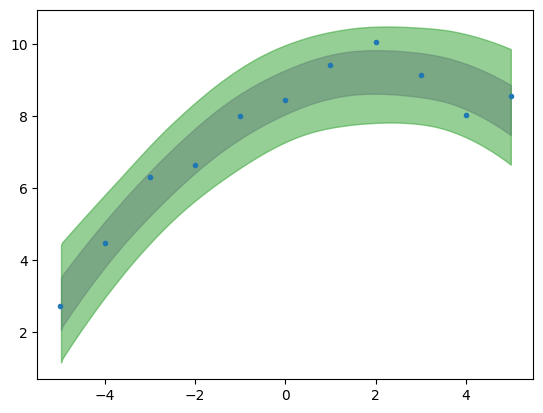

In [72]:
plt.plot(x,yn,'C0.')
az.plot_hdi(x,ppc.posterior_predictive['y_pred'],color='C4',hdi_prob=.68)
az.plot_hdi(x,ppc.posterior_predictive['y_pred'],color='C2',hdi_prob=.95)

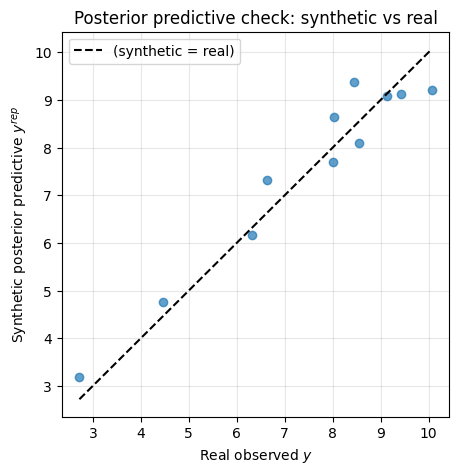

In [75]:
# posterior predictive samples

y_rep = ppc.posterior_predictive["y_pred"]

# stack chain and draw into one dimension

y_rep_stacked = y_rep.stack(sample=("chain", "draw"))

# choose one posterior predictive sample

idx = np.random.randint(y_rep_stacked.sizes["sample"])

y_synthetic = y_rep_stacked.isel(sample=idx).values

# use the real observed data

y_real = yn   # or y, depending on what you used as observed data

plt.figure(figsize=(5, 5))

plt.plot(y_real, y_synthetic, "C0o", alpha=0.7)

# diagonal reference line

ymin = min(np.min(y_real), np.min(y_synthetic))

ymax = max(np.max(y_real), np.max(y_synthetic))

plt.plot([ymin, ymax], [ymin, ymax], "k--", label="(synthetic = real)")

plt.xlabel("Real observed $y$")

plt.ylabel("Synthetic posterior predictive $y^{rep}$")

plt.title("Posterior predictive check: synthetic vs real")

plt.legend()

plt.grid(alpha=0.3)

plt.show()